In [1]:
import pandas as pd               # For data manipulation and analysis
import numpy as np                # For numerical operations
import matplotlib.pyplot as plt   # For plotting and visualization
import seaborn as sns             # For enhanced statistical plots

# Import functions and models from scikit-learn
from sklearn.model_selection import train_test_split  # To split data into training and testing sets
from sklearn.linear_model import LogisticRegression     # Linear model for classification
from sklearn.tree import DecisionTreeClassifier         # Tree-based model for classification
from sklearn.ensemble import RandomForestClassifier       # Ensemble of decision trees
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # Evaluation metrics

In [2]:
# Step 2: Load the Dataset
data_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"


In [4]:
titanic_df = pd.read_csv(data_url)

In [13]:
# Step 3: Exploratory Data Analysis (EDA)
# -----------------------------

# Display the first 5 rows of the dataset to understand its structure
print("First 5 rows of the dataset:")
print(titanic_df.head())

First 5 rows of the dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450

In [14]:
# Display summary information about the dataset including non-null counts and data types
print("\nDataset Information:")
print(titanic_df.info())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [15]:
# Display statistical summary for numerical columns
print("\nStatistical Summary:")
print(titanic_df.describe())



Statistical Summary:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [16]:
# Check for missing values in each column to plan for cleaning
print("\nMissing Values in Each Column:")
print(titanic_df.isnull().sum())



Missing Values in Each Column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


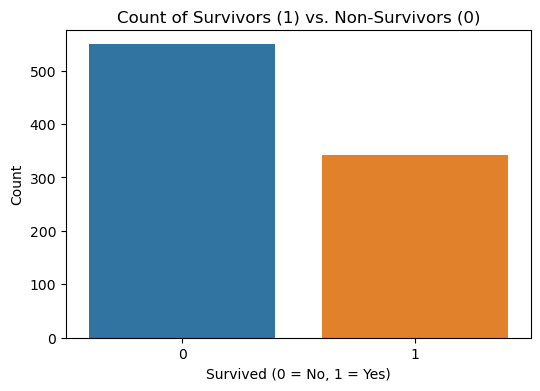

In [17]:
# Visualize the count of survivors vs. non-survivors using a countplot
plt.figure(figsize=(6, 4))                         # Set figure size for better readability
sns.countplot(x="Survived", data=titanic_df)         # Count plot for 'Survived' column
plt.title("Count of Survivors (1) vs. Non-Survivors (0)")  # Add title to the plot
plt.xlabel("Survived (0 = No, 1 = Yes)")            # Label for x-axis
plt.ylabel("Count")                                # Label for y-axis
plt.show()                                         # Display the plot

In [19]:
# -----------------------------
# Step 4: Data Cleaning and Preprocessing
# -----------------------------

# Drop columns that are not useful for prediction: 'PassengerId', 'Name', 'Ticket', 'Cabin'
titanic_df_clean = titanic_df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

# Fill missing values in the 'Age' column with the median age
titanic_df_clean['Age'] = titanic_df_clean['Age'].fillna(titanic_df_clean['Age'].median())

In [20]:
# Fill missing values in the 'Embarked' column with the mode (most common port)
titanic_df_clean['Embarked'] = titanic_df_clean['Embarked'].fillna(titanic_df_clean['Embarked'].mode()[0])

In [21]:
# Convert categorical variables ('Sex' and 'Embarked') into dummy/indicator variables
# 'drop_first=True' is used to avoid multicollinearity by dropping the first category
titanic_df_clean = pd.get_dummies(titanic_df_clean, columns=['Sex', 'Embarked'], drop_first=True)

In [22]:
# Display the first 5 rows of the cleaned dataset to verify changes
print("\nCleaned Dataset Preview:")
print(titanic_df_clean.head())


Cleaned Dataset Preview:
   Survived  Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  \
0         0       3  22.0      1      0   7.2500      True       False   
1         1       1  38.0      1      0  71.2833     False       False   
2         1       3  26.0      0      0   7.9250     False       False   
3         1       1  35.0      1      0  53.1000     False       False   
4         0       3  35.0      0      0   8.0500      True       False   

   Embarked_S  
0        True  
1       False  
2        True  
3        True  
4        True  


In [25]:
# Step 5: Define Features and Target Variable# Define 'X' as the features (all columns except 'Survived')
X = titanic_df_clean.drop('Survived', axis=1)

# Define 'y' as the target variable ('Survived')
y = titanic_df_clean['Survived']

In [26]:
# Step 6: Split the Data into Training and Testing Sets
# Split data into training and testing sets with 80% for training and 20% for testing
# 'random_state=42' ensures reproducibility of the results
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [27]:
# --- Model 1: Logistic Regression ---
# Logistic Regression is a linear model that is easy to interpret and works well when the relationship 
# between the independent variables and the target is roughly linear.
logreg = LogisticRegression(max_iter=1000)  # Initialize Logistic Regression with a higher iteration limit
logreg.fit(X_train, y_train)                # Train the model on the training data
y_pred_logreg = logreg.predict(X_test)        # Predict the target variable on the test set

In [28]:
y_pred_logreg = logreg.predict(X_test)        # Predict the target variable on the test set
# Evaluate Logistic Regression using accuracy score, confusion matrix, and classification report
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
print("\nLogistic Regression Accuracy: {:.2f}%".format(accuracy_logreg * 100))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_logreg))
print("Classification Report:\n", classification_report(y_test, y_pred_logreg))


Logistic Regression Accuracy: 81.01%
Confusion Matrix:
 [[90 15]
 [19 55]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [29]:
# --- Model 2: Decision Tree Classifier ---
# Decision Trees are non-linear models that can capture complex interactions between features.
# They are intuitive as they mimic human decision-making processes.
dtree = DecisionTreeClassifier(random_state=42)  # Initialize the Decision Tree classifier with a fixed random state
dtree.fit(X_train, y_train)                      # Train the Decision Tree on the training data


In [30]:
y_pred_dtree = dtree.predict(X_test)             # Predict the target variable on the test set
# Evaluate Decision Tree using accuracy score, confusion matrix, and classification report
accuracy_dtree = accuracy_score(y_test, y_pred_dtree)
print("\nDecision Tree Accuracy: {:.2f}%".format(accuracy_dtree * 100))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dtree))
print("Classification Report:\n", classification_report(y_test, y_pred_dtree))


Decision Tree Accuracy: 78.21%
Confusion Matrix:
 [[84 21]
 [18 56]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.80      0.81       105
           1       0.73      0.76      0.74        74

    accuracy                           0.78       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.78      0.78      0.78       179



In [31]:
# --- Model 3: Random Forest Classifier ---
# Random Forest is an ensemble method that builds multiple decision trees and averages their predictions.
# It usually offers higher accuracy and robustness against overfitting than a single decision tree.
rf = RandomForestClassifier(n_estimators=100, random_state=42)  # Initialize Random Forest with 100 trees
rf.fit(X_train, y_train)                                         # Train the Random Forest on the training data


RandomForestClassifier(random_state=42)

In [32]:
y_pred_rf = rf.predict(X_test)                                   # Predict the target variable on the test set
# Evaluate Random Forest using accuracy score, confusion matrix, and classification report
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("\nRandom Forest Accuracy: {:.2f}%".format(accuracy_rf * 100))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 82.12%
Confusion Matrix:
 [[91 14]
 [18 56]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [33]:
# -----------------------------
# Step 8: Compare Model Performances and Discuss Model Selection
# -----------------------------

# Print a summary of accuracies for each model for quick comparison
print("\nSummary of Model Accuracies:")
print("Logistic Regression: {:.2f}%".format(accuracy_logreg * 100))
print("Decision Tree      : {:.2f}%".format(accuracy_dtree * 100))
print("Random Forest      : {:.2f}%".format(accuracy_rf * 100))


Summary of Model Accuracies:
Logistic Regression: 81.01%
Decision Tree      : 78.21%
Random Forest      : 82.12%


In [34]:
# Discussion on Model Selection:
#
# 1. Logistic Regression:
#    - Advantages: Simplicity, speed, and interpretability (coefficients can indicate feature importance).
#    - When to use: When the relationship between features and the target is approximately linear and 
#      when interpretability is key.
#
# 2. Decision Tree:
#    - Advantages: Captures non-linear relationships and interactions between features; easy to visualize.
#    - When to use: When you need an intuitive model that can handle complex datasets with non-linear patterns.
#
# 3. Random Forest:
#    - Advantages: Generally provides higher accuracy by reducing overfitting through averaging multiple trees.
#    - When to use: When prediction accuracy is the primary goal and the dataset has complex interactions.
#
# In practice, the choice of model depends on several factors:
#    - The nature of the data (linear vs. non-linear relationships).
#    - The size of the dataset.
#    - The need for model interpretability.
#    - The trade-off between bias and variance.
#
# For instance, if interpretability is important (such as in a medical application), one might prefer 
# Logistic Regression despite slightly lower accuracy. On the other hand, if accuracy is the primary concern, 
# especially when the data has complex patterns, Random Forest may be the better choice.